# Paper plots

Figures for the paper, built from `data/survey_results.xlsx`. Variable names, value labels and quiz keys come
from `docs/coding_sheet.csv`; cleaning and scoring follow `docs/analysis_plan.md`.
Outputs are aggregates only; no student codes are printed.

## Init

In [1]:
import re
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, PercentFormatter
from matplotlib.transforms import offset_copy

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "docs" / "coding_sheet.csv").exists())
DATA_FILE = ROOT / "data" / "survey_results.xlsx"
CODING_SHEET = ROOT / "docs" / "coding_sheet.csv"
FIGURES = ROOT / "figures"
TABLES = ROOT / "tables"

# Manual pairing recoveries {post-test code: pre-test code}, for post-test codes that match no pre-test code.
MANUAL_MATCHES = {}
# Quiz items answered = not blank ("I do not know" counts as an answer). Parts A and B use only students with at
# least MIN_ANSWERED items answered (Part A at the pre-test, Part B at both waves). The score plot and the per-item
# plot use a wave with at least MIN_ANSWERED items; the score plot draws it in black from FULL_ANSWERED on.
MIN_ANSWERED, FULL_ANSWERED = 5, 15

WAVES = ["pre", "post"]

# Colours (dataviz reference palette): ink and chrome, categorical slots, diverging ramp.
SURFACE, INK, INK_2, MUTED, LIGHT_GREY, GRID = "#ffffff", "#0b0b0b", "#52514e", "#898781", "#b5b4ad", "#e1e0d9"
WAVE_COLORS = {"pre": "#eb6834", "post": "#2a78d6"}
CHANGE_COLORS = {"up": "#0ca30c", "same": "#b5b4ad", "down": "#d03b3b"}
DIVERGING_5 = ["#d03b3b", "#f0a9a8", "#d6d5d0", "#9ec5f4", "#2a78d6"]  # disagree -> agree
ORDINAL_5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # low -> high

# Stacked bars are equally thick in every figure of the paper: figures 8 in wide go to \columnwidth, 16 in wide to
# \textwidth (IEEEtran, in inches), and one bar row is ROW_HEIGHT_PT high there (the bar fills 0.72 of it).
PAPER_WIDTH = {8: 3.5, 16: 7.16}
ROW_HEIGHT_PT = 15

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": GRID, "grid.color": GRID, "axes.labelcolor": INK_2,
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK, "axes.titleweight": "bold",
    "axes.titlesize": 11, "axes.titlelocation": "left", "legend.frameon": False,
})


def save_pdf(fig, name):
    """Save a figure as figures/<name>.pdf, cropped tightly to its content."""
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / f"{name}.pdf", bbox_inches="tight")


def save_tex(text, name):
    """Save a LaTeX table as tables/<name>.tex (needs booktabs and multirow)."""
    TABLES.mkdir(exist_ok=True)
    (TABLES / f"{name}.tex").write_text(text)


def tex(text):
    """Plain text -> LaTeX: escape specials, en dash in number ranges, math-mode < and >."""
    text = re.sub(r"([&%$#_{}])", r"\\\1", str(text))
    text = re.sub(r"(\d)-(\d)", r"\1--\2", text)
    return text.replace("<", "$<$").replace(">", "$>$")


def tex_header(text):
    """Column header; 'no answer' on two lines to keep the column narrow."""
    return r"\shortstack{no\\answer}" if text == "no answer" else tex(text)


def pre_post_cell(text):
    """'15 / 7' -> '15\\,/\\,7' (thin spaces keep the pre / post cells narrow)."""
    return str(text).replace(" / ", r"\,/\,")


def wrap(text, width=38):
    return "\n".join(textwrap.wrap(str(text), width, break_long_words=False))


def wrap_balanced(text, lines=2):
    """Wrap into at most `lines` lines of similar length (the narrowest width that still fits)."""
    width = next(w for w in range(len(text) // lines, len(text) + 1) if len(textwrap.wrap(text, w)) <= lines)
    return wrap(text, width)


def title_case(text, small=("a", "an", "and", "of", "or", "the", "to", "in", "for")):
    """'sub-agents and A2A' -> 'Sub-Agents and A2A': capitalise each word part, keep acronyms and small words."""
    words = text.split(" ")
    return " ".join(w if i > 0 and w in small else "-".join(p[:1].upper() + p[1:] for p in w.split("-"))
                    for i, w in enumerate(words))


def legend_below(ax, ncol, **kwargs):
    """Legend centred under the x tick labels, independent of the figure height."""
    below_ticks = offset_copy(ax.transAxes, fig=ax.figure, y=-24, units="points")
    ax.legend(ncol=ncol, loc="upper center", bbox_to_anchor=(0.5, 0), bbox_transform=below_ticks,
              fontsize=9, handlelength=1, columnspacing=1, **kwargs)


def plot_stacked(ax, frame, value_labels, colors, row_labels, title, label_width=40, legend=True):
    """100% stacked horizontal bars: one row per item, one segment per response code.
    label_width=None uses row_labels as given (already wrapped)."""
    codes = list(value_labels)
    counts = pd.DataFrame({c: frame[c].value_counts() for c in frame.columns}).reindex(codes).fillna(0).T
    n = counts.sum(axis=1)
    share = counts.div(n.replace(0, np.nan), axis=0).fillna(0)
    y = np.arange(len(share))
    left = np.zeros(len(share))
    for code, color in zip(codes, colors):
        ax.barh(y, share[code], left=left, color=color, edgecolor=SURFACE, linewidth=1.5, height=0.72,
                label=value_labels[code])
        left += share[code].to_numpy()
    ax.set_yticks(y, [row_labels[c] if label_width is None else wrap(row_labels[c], label_width) for c in share.index])
    ax.set_ylim(len(y) - 0.5, -0.5)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(False)
    ax.set_title(title)
    if legend:
        legend_below(ax, len(codes))


def fit_rows(fig, ax, n_rows):
    """Set the figure height so that each of the n_rows bar rows of ax is ROW_HEIGHT_PT high in the paper.
    Constrained layout changes the axes height with the figure height, so a few rounds converge."""
    row_inches = ROW_HEIGHT_PT / 72 * fig.get_figwidth() / PAPER_WIDTH[round(fig.get_figwidth())]
    for _ in range(4):
        fig.canvas.draw()
        height = ax.get_window_extent().height / fig.dpi
        fig.set_figheight(fig.get_figheight() + n_rows * row_inches - height)


AGREE = {1: "1 strongly disagree", 2: "2 disagree", 3: "3 neutral", 4: "4 agree", 5: "5 strongly agree"}


def plot_agreement(texts, suptitle):
    """Part B agreement items as stacked bars, pre and post side by side; per item only the students who
    rated it at both waves. The item labels carry the pre and post means; the n per item is printed
    (for the caption), not plotted."""
    frames = {wave: wave_items(list(texts), wave, paired_only=True) for wave in WAVES}
    means = {wave: frame.astype(float).mean() for wave, frame in frames.items()}
    n = frames["pre"].notna().sum()
    print(f"{suptitle}: n={n.min()}" + ("" if n.min() == n.max() else f"–{n.max()} per item"))
    labels = {v: wrap_balanced(f"{text} (mean: pre={means['pre'][v]:.2f}; post={means['post'][v]:.2f})")
              for v, text in texts.items()}
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), constrained_layout=True, sharey=True)
    for ax, wave, wave_title in zip(axes, WAVES, ["Pre-test", "Post-test"]):
        plot_stacked(ax, frames[wave], AGREE, DIVERGING_5, labels, wave_title, label_width=None,
                     legend=wave == "pre")
    fig.suptitle(suptitle, fontweight="bold", fontsize=12)
    fit_rows(fig, axes[0], len(texts))
    return fig


def spread(values, left_first, order_by, width):
    """Horizontal offsets that fan out students with the same score side by side, centred on 0.
    Within a tie, students flagged in left_first go left; after that they are ordered by order_by (their score
    at the other wave) to limit line crossings."""
    offsets = pd.Series(0.0, index=values.index)
    for _, group in values.dropna().groupby(values.dropna()):
        keys = pd.DataFrame({"right": ~left_first[group.index], "other": order_by[group.index]})
        ordered = keys.sort_values(["right", "other"], na_position="last").index
        offsets[ordered] = (np.arange(len(ordered)) - (len(ordered) - 1) / 2) * width
    return offsets


def plot_scores(ax, pre, post, full_pre, full_post, title, lim, ytick=5, spacing=0.05):
    """One line per student with both waves; a lone marker for a student with only one wave. Students with the
    same score at a wave sit side by side, spacing apart, black markers left of grey ones.
    Line styles that no student has are left out of the legend.
    full_pre / full_post flag the waves with at least FULL_ANSWERED items answered: black marker, and a solid
    black line if both waves are full, a dashed black line if one is, a dashed light grey line if neither is.
    Medians are over every student shown on that side."""
    x_pre, x_post = spread(pre, full_pre, post, spacing), 1 + spread(post, full_post, pre, spacing)
    both = pre.notna() & post.notna()
    line_styles = {2: (INK, "-"), 1: (INK, "--"), 0: (LIGHT_GREY, "--")}
    n_full = full_pre.astype(int) + full_post.astype(int)
    for s in pre.index[both]:
        color, style = line_styles[n_full[s]]
        ax.plot([x_pre[s], x_post[s]], [pre[s], post[s]], color=color, linestyle=style, linewidth=1.2,
                alpha=0.8, zorder=2)
    for x, xs, values, full in [(0, x_pre, pre, full_pre), (1, x_post, post, full_post)]:
        shown = values.notna()
        ax.scatter(xs[shown], values[shown], s=34, zorder=3,
                   color=np.where(full[shown], INK, LIGHT_GREY), edgecolor=SURFACE, linewidth=0.8)
        ax.hlines(values.median(), x - 0.2, x + 0.2, color=WAVE_COLORS["post"], linewidth=2.5, zorder=1)
    ax.set_xticks([0, 1], ["Pre-test", "Post-test"])
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(*lim)
    ax.yaxis.set_major_locator(MultipleLocator(ytick))
    ax.grid(axis="x", visible=False)
    ax.set_title(title)
    counts = n_full[both].value_counts()
    print("Students per line style:", {label: int(counts.get(k, 0)) for k, label in
                                       [(2, "both full"), (1, "one full"), (0, "neither full")]})
    lines = [Line2D([], [], color=c, linestyle=ls, label=label) for k, label, (c, ls) in
               [(2, f"both waves ≥ {FULL_ANSWERED} answered", line_styles[2]),
                (1, f"one wave ≥ {FULL_ANSWERED} answered", line_styles[1]),
                (0, f"both waves < {FULL_ANSWERED} answered", line_styles[0])] if counts.get(k, 0) > 0]
    lines.append(Line2D([], [], color=WAVE_COLORS["post"], linewidth=2.5, label="median"))
    dots = [Line2D([], [], color=c, linestyle="none", marker="o", markersize=5, label=label) for c, label in
            [(INK, f"≥ {FULL_ANSWERED} items answered"), (LIGHT_GREY, f"{MIN_ANSWERED}–{FULL_ANSWERED - 1} items answered")]]
    # Two legend rows under the x tick labels: line styles and median first, marker colours second.
    for handles, y in [(lines, -30), (dots, -46)]:
        below_ticks = offset_copy(ax.transAxes, fig=ax.figure, y=y, units="points")
        legend = ax.legend(handles=handles, ncol=len(handles), loc="upper center", bbox_to_anchor=(0.5, 0),
                           bbox_transform=below_ticks, fontsize=9, handlelength=2, columnspacing=1.2,
                           borderaxespad=0, borderpad=0)
        if handles is lines:
            # The second ax.legend call replaces ax.legend_, so keep the first row as a plain artist.
            ax.add_artist(legend)
            legend.set_clip_on(False)

def plot_sankey(ax, flows, nodes, colors, stage_titles, gap=0.6, node_width=0.06):
    """Two-stage Sankey: flows is a Series of counts indexed by (left node, right node); nodes lists the node
    names top to bottom (a node without students is left out). Bands take the colour of their left node and
    stack inside each node in the order of the node list, which keeps crossings down. Every node is labelled
    with its name and n, every band with its n at its left end, where bands never overlap."""
    order = {name: i for i, name in enumerate(nodes)}
    flows = flows[flows > 0]
    sides = [flows.groupby(level=k).sum().reindex(nodes).dropna() for k in (0, 1)]
    tops = []
    for x, totals in zip((0, 1), sides):
        top, positions = 0.0, {}
        for name, n in totals.items():
            positions[name] = top
            ax.add_patch(plt.Rectangle((x - node_width / 2 if x else -node_width, -top - n), node_width, n,
                                       color=colors[name], linewidth=0, zorder=3))
            ax.text(x + (node_width + 0.02) * (1 if x else -1), -top - n / 2, f"{name}  (n={int(n)})",
                    ha="left" if x else "right", va="center", fontsize=9, color=INK)
            top += n + gap
        tops.append(positions)
    x0, x1 = 0.0, 1 - node_width / 2
    out_offset, in_offset = dict.fromkeys(nodes, 0.0), dict.fromkeys(nodes, 0.0)
    ordered = sorted(flows.items(), key=lambda kv: (order[kv[0][0]], order[kv[0][1]]))
    # Incoming bands stack by the order of their source node, so they are placed in a second pass.
    y_in = {}
    for (src, dst), n in sorted(flows.items(), key=lambda kv: (order[kv[0][1]], order[kv[0][0]])):
        y_in[src, dst] = -tops[1][dst] - in_offset[dst]
        in_offset[dst] += n
    for (src, dst), n in ordered:
        ya, yb = -tops[0][src] - out_offset[src], y_in[src, dst]
        out_offset[src] += n
        t = np.linspace(0, 1, 60)
        s = 3 * t ** 2 - 2 * t ** 3  # smoothstep: horizontal at both ends
        xs = x0 + (x1 - x0) * t
        upper, lower = ya + (yb - ya) * s, ya - n + (yb - ya) * s
        ax.fill_between(xs, lower, upper, color=colors[src], alpha=0.45, linewidth=0, zorder=2)
        ax.text(0.03, ya - n / 2, int(n), ha="left", va="center", fontsize=8, color=INK,
                zorder=4, bbox=dict(boxstyle="round,pad=0.15", fc=SURFACE, ec="none", alpha=0.8))
    for x, title in zip((0, 1), stage_titles):
        ax.text(x - node_width / 2 if x == 0 else x, 1.0, title, ha="center", va="bottom", fontsize=11,
                fontweight="bold", color=INK)
    height = max(sum(s) + gap * (len(s) - 1) for s in sides)
    ax.set_xlim(-0.75, 1.75)
    ax.set_ylim(-height - 0.5, 2.5)
    ax.axis("off")


## Data loading and cleaning

In [2]:
codebook = pd.read_csv(CODING_SHEET, dtype=str, keep_default_na=False).set_index("variable")


def col(var, wave):
    """Column name in the entry workbook: variables measured at both waves carry a wave prefix."""
    return f"{wave}_{var}" if codebook.at[var, "wave"] == "both" else var


def value_labels(var):
    """'1 = none; 2 = <1 year' -> {1: 'none', 2: '<1 year'};  '1-5 (forced choice)' -> {1: '1', ..., 5: '5'}."""
    values = codebook.at[var, "values"]
    m = re.match(r"^(\d+)\s*-\s*(\d+)(\s|\(|$)", values)
    if m and ";" not in values:
        return {i: str(i) for i in range(int(m[1]), int(m[2]) + 1)}
    labels = {}
    for part in values.split(";"):
        code, _, label = part.partition("=")
        if code.strip().lstrip("-").isdigit():
            labels[int(code)] = label.strip() or code.strip()
    return labels


def short_label(var):
    """'Self-rated skill: Python' -> 'Python'."""
    return codebook.at[var, "label"].split(": ", 1)[-1]


raw = pd.read_excel(DATA_FILE, sheet_name="Data").dropna(how="all").reset_index(drop=True)
pre_cols = [c for c in raw.columns if c.startswith("pre_")]
post_cols = [c for c in raw.columns if c.startswith("post_") or
             (c in codebook.index and codebook.at[c, "wave"] == "post")]
for post_code, pre_code in MANUAL_MATCHES.items():
    src, dst = raw.index[raw["code"] == post_code][0], raw.index[raw["code"] == pre_code][0]
    raw.loc[dst, post_cols] = raw.loc[src, post_cols]
    raw = raw.drop(index=src)
raw = raw.reset_index(drop=True)
# A6 use, A7 prior experience and A′3 involvement are entered in the form's column order (most first); they are
# analysed the other way round, so that a higher code means more. Out-of-range codes stay as entered.
REVERSED = {
    "use_": "1 = never; 2 = tried once; 3 = monthly; 4 = weekly; 5 = daily",
    "built_": "1 = no; 2 = attempted; 3 = yes",
    "own_": "1 = not involved/not built; 2 = reviewed only; 3 = co-built; 4 = built it",
}
for prefix, values in REVERSED.items():
    top = len(values.split(";"))
    for v in [v for v in codebook.index if v.startswith(prefix)]:
        x = pd.to_numeric(raw[v], errors="coerce")
        raw[v] = x.where(~x.between(1, top), top + 1 - x)
        codebook.at[v, "values"] = values
has_wave = {"pre": raw[pre_cols].notna().any(axis=1), "post": raw[post_cols].notna().any(axis=1)}

# Paired students (both waves) for Part B; the index stays the row number in raw.
df = raw[has_wave["pre"] & has_wave["post"]].copy()
print(f"Returned: pre {has_wave['pre'].sum()}, post {has_wave['post'].sum()}, both waves {len(df)}")

# Out-of-range Part B codes -> missing.
repeated = [v for v in codebook.index if codebook.at[v, "wave"] == "both"
            and codebook.at[v, "part"] == "B" and value_labels(v)]
for v in repeated:
    for wave in WAVES:
        values = pd.to_numeric(df[col(v, wave)], errors="coerce")
        df[col(v, wave)] = values.where(values.isin(list(value_labels(v)))).astype("Int64")

Returned: pre 34, post 17, both waves 16


In [3]:
# --- Part B item wording (survey/common/part_b_selfassessment.tex) -----------------------------
B1_TEXT = {
    "b1_01": "I know what the components of an agentic system are, how they work, and the role each fulfils.",
    "b1_02": "I understand how these components interact, and how that extends what an agent can do.",
    "b1_03": "I understand how to ensure the quality of the components and of the system as a whole.",
    "b1_04": "I understand which telemetry data is relevant for monitoring an agentic system.",
    "b1_05": "I could implement, monitor, and maintain an agentic system, incl. code, tests, and telemetry.",
}
B3_TEXT = {
    "b3_01": "… design the architecture of an agent harness from scratch, given requirements.",
    "b3_02": "… work out why a particular agent run failed, given its logs and traces.",
    "b3_03": "… decide what should be measured to operate an agentic system in production.",
    "b3_04": "… judge whether someone else's agent harness is well built.",
    "b3_05": "… explain to a non-expert why an agent needs a harness at all.",
}
B2_COMPONENTS = [v.removeprefix("b2_expl_") for v in codebook.index if v.startswith("b2_expl_")]
B2_TEXT = {c: title_case(short_label(f"b2_expl_{c}")) for c in B2_COMPONENTS}


def wave_items(items, wave, paired_only=False):
    """Part B items at one wave, with the wave prefix stripped from the column names.
    paired_only keeps a rating only where the student rated the same item at the other wave too."""
    frame = df[[col(v, wave) for v in items]].set_axis(items, axis=1)
    if paired_only:
        other = "post" if wave == "pre" else "pre"
        frame = frame.where(df[[col(v, other) for v in items]].set_axis(items, axis=1).notna())
    return frame


# --- Part C: keys, topics, scoring over every returned wave (not only paired students) -------
ITEMS = [f"q{i:02d}" for i in range(1, 21)]
TOPIC_NAMES = {
    "T1": "LLM role & statelessness", "T2": "Context engineering", "T3": "Loop & control flow",
    "T4": "Tools & tool design", "T5": "MCP", "T6": "Skills", "T7": "Long-term memory", "T8": "Hooks",
    "T9": "Permission management", "T10": "Sandboxing", "T11": "Sub-agents & A2A",
    "T12": "Observability & telemetry", "T13": "Quality assurance",
}
item_meta = []
for q in ITEMS:
    key_a, key_b = re.search(r"Key A = \((\w)\), key B = \((\w)\)", codebook.at[f"{q}_score", "notes"]).groups()
    topic = re.search(r"\((T\d+),", codebook.at[f"{q}_resp", "label"])[1]
    item_meta.append({"item": q, "key_A": key_a, "key_B": key_b, "topic": topic})
item_meta = pd.DataFrame(item_meta).set_index("item")
ITEM_LABELS = {q: f"Q{q[1:]}: {TOPIC_NAMES[r.topic]}" for q, r in item_meta.iterrows()}

quiz_long = []
for wave in WAVES:
    rows = raw[has_wave[wave] & raw[f"{wave}_form"].isin(["A", "B"])]
    responses = rows[[f"{wave}_{q}_resp" for q in ITEMS]].set_axis(ITEMS, axis=1)
    responses = responses.apply(lambda s: s.astype("string").str.strip().str.lower())
    responses = responses.where(responses.isin(["a", "b", "c", "d", "dk", "multi"]))
    long = (responses.assign(student=rows.index, form=rows[f"{wave}_form"])
            .melt(id_vars=["student", "form"], var_name="item", value_name="response"))
    long["wave"] = wave
    quiz_long.append(long)
quiz_long = pd.concat(quiz_long, ignore_index=True)
quiz_long["key"] = [item_meta.at[q, f"key_{f}"] for q, f in zip(quiz_long["item"], quiz_long["form"])]
quiz_long["score"] = (quiz_long["response"] == quiz_long["key"]).fillna(False).astype(int)

per_wave = quiz_long.groupby(["wave", "student"]).agg(total=("score", "sum"), answered=("response", "count"))
answered = per_wave["answered"].unstack("wave").reindex(columns=WAVES)
totals = per_wave["total"].unstack("wave").reindex(columns=WAVES).where(answered >= MIN_ANSWERED)
full = answered >= FULL_ANSWERED
# Parts A and B: only students with at least MIN_ANSWERED quiz items answered (Part B: at both waves).
quiz_ok = (answered >= MIN_ANSWERED).reindex(raw.index, fill_value=False)
df = df[quiz_ok.loc[df.index].all(axis=1)]
print(f"Part B (both waves, at least {MIN_ANSWERED} quiz items answered at each): {len(df)} students")
quiz = quiz_long.set_index(["wave", "student"]).loc[
    per_wave.index[per_wave["answered"] >= MIN_ANSWERED]].reset_index()
for label, n in [(f"at least {MIN_ANSWERED}", MIN_ANSWERED), (f"at least {FULL_ANSWERED}", FULL_ANSWERED)]:
    ok = answered >= n
    print(f"Quiz waves with {label} items answered: pre {ok['pre'].sum()}, post {ok['post'].sum()}, "
          f"both {ok.all(axis=1).sum()}")

Part B (both waves, at least 5 quiz items answered at each): 13 students
Quiz waves with at least 5 items answered: pre 29, post 15, both 13
Quiz waves with at least 15 items answered: pre 25, post 14, both 11


## Participation, pre → post

Every student with a returned form at either wave, grouped per wave by the number of quiz items answered (not blank;
"I do not know" counts as an answer). A band follows the students from their pre-test group to their post-test
group; the numbers on the bands and nodes are student counts.

post           ≥ 15 answered  5–14 answered  < 5 answered  not taken  All
pre                                                                      
≥ 15 answered             11              0             2         12   25
5–14 answered              2              0             0          2    4
< 5 answered               0              1             0          4    5
not taken                  1              0             0          0    1
All                       14              1             2         18   35


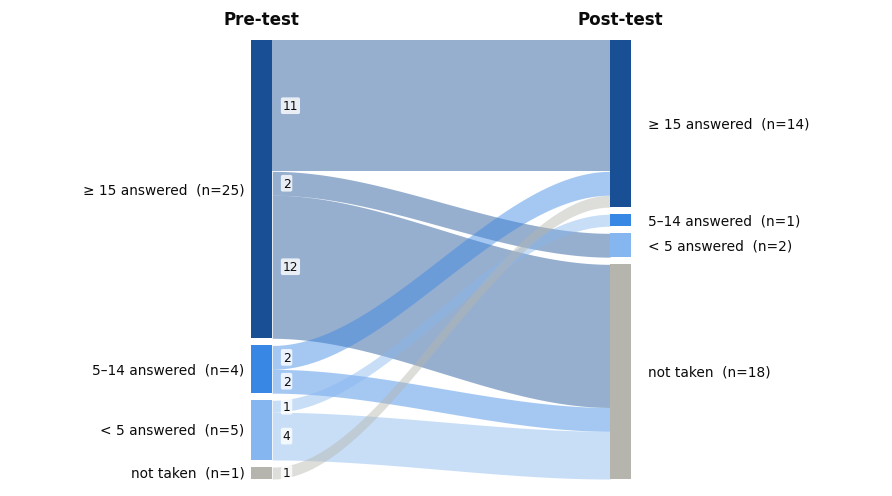

In [4]:
BUCKETS = [(FULL_ANSWERED, f"≥ {FULL_ANSWERED}"), (MIN_ANSWERED, f"{MIN_ANSWERED}–{FULL_ANSWERED - 1}"),
           (0, f"< {MIN_ANSWERED}")]
ABSENT = "not taken"
PARTICIPATION_NODES = [f"{b} answered" for _, b in BUCKETS] + [ABSENT]
# Blue ramp, darker = more items answered.
PARTICIPATION_COLORS = dict(zip(PARTICIPATION_NODES, ["#184f95", "#3987e5", "#86b6ef", LIGHT_GREY]))


def participation(wave):
    """Participation group per student (row in raw) at one wave."""
    n_answered = answered[wave].reindex(raw.index).fillna(0)
    group = pd.Series([next(label for lo, label in BUCKETS if n >= lo) + " answered" for n in n_answered],
                      index=raw.index)
    return group.where(has_wave[wave], ABSENT)


groups = pd.DataFrame({wave: participation(wave) for wave in WAVES})
print(pd.crosstab(groups["pre"], groups["post"], margins=True).reindex(
    index=PARTICIPATION_NODES + ["All"], columns=PARTICIPATION_NODES + ["All"]).fillna(0).astype(int).to_string())

fig, ax = plt.subplots(figsize=(8, 4.4), constrained_layout=True)
plot_sankey(ax, groups.value_counts(["pre", "post"]), PARTICIPATION_NODES, PARTICIPATION_COLORS,
            ["Pre-test", "Post-test"])
save_pdf(fig, "participation")
plt.show()

## Quiz score, pre → post

Every student with at least 5 quiz items answered at a wave is shown on that side; the marker is black from 15
answered items on and light grey below. A line joins the two waves for a student shown at both: solid black if both
waves have at least 15 answered items, dashed black if one has, dashed light grey if neither has. Students with the same score
at a wave are placed side by side, black markers left of grey ones. The blue bars are the
medians over all students on that side.

Students per line style: {'both full': 11, 'one full': 2, 'neither full': 0}


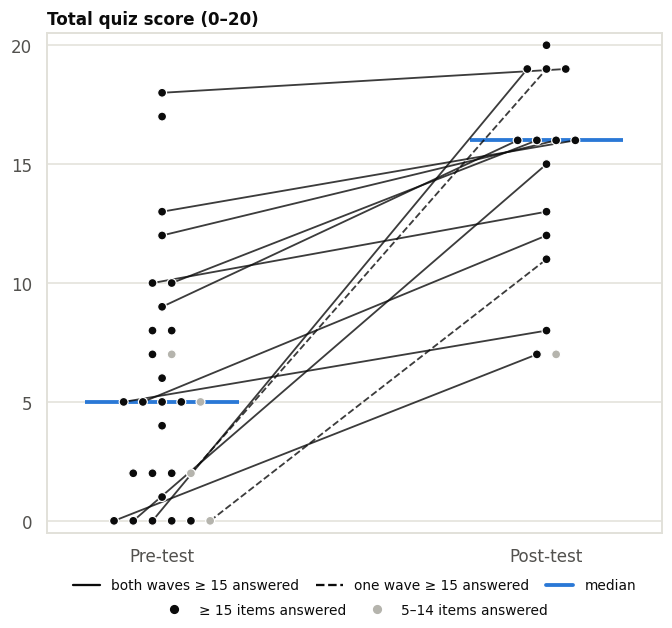

In [5]:
fig, ax = plt.subplots(figsize=(6, 5.6), constrained_layout=True)
plot_scores(ax, totals["pre"], totals["post"], full["pre"], full["post"], "Total quiz score (0–20)",
            lim=(-0.5, 20.5))
save_pdf(fig, "quiz_scores")
plt.show()

## Quiz score per item, pre → post

Proportion correct per item among the students with at least 5 quiz items answered at that wave. The line
spans the change from pre to post.

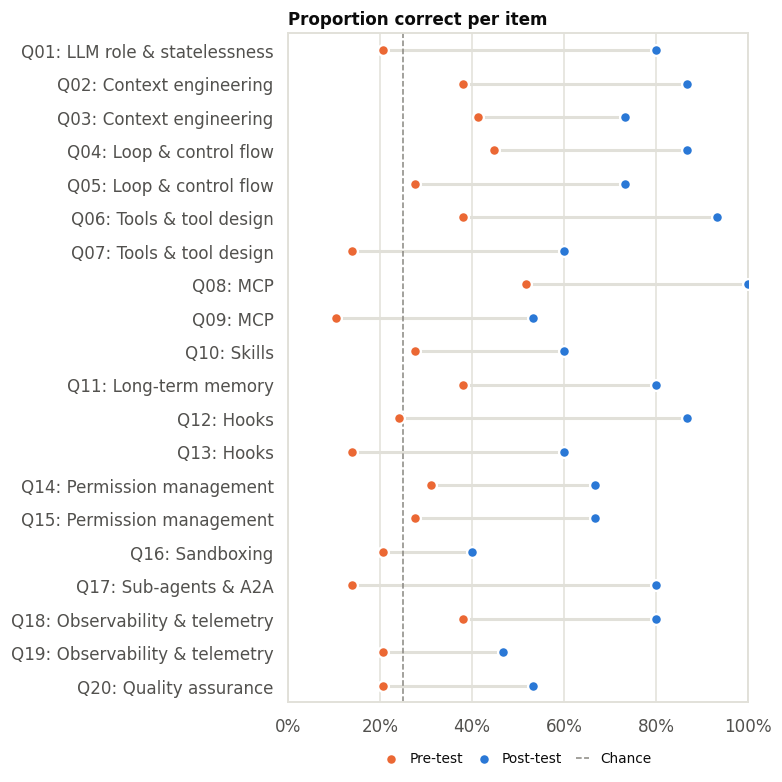

In [6]:
p_item = quiz.groupby(["item", "wave"])["score"].mean().unstack()[WAVES].reindex(ITEMS)

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
y = np.arange(len(ITEMS))
ax.hlines(y, p_item.min(axis=1), p_item.max(axis=1), color=GRID, linewidth=2)
for wave, label in zip(WAVES, ["Pre-test", "Post-test"]):
    ax.scatter(p_item[wave], y, s=50, color=WAVE_COLORS[wave], edgecolor=SURFACE, linewidth=1.5, zorder=3,
               label=label)
ax.axvline(0.25, color=MUTED, linewidth=1, linestyle="--", label="Chance")
ax.set_yticks(y, [ITEM_LABELS[q] for q in ITEMS])
ax.set_ylim(len(y) - 0.5, -0.5)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", visible=False)
ax.set_title("Proportion correct per item")
legend_below(ax, 3)
save_pdf(fig, "quiz_items")
plt.show()

## B1 learning objectives, pre and post side by side

Paired students with at least 5 quiz items answered at both waves; per item, only students who rated that item at both waves.

Self-assessment of the learning objectives: n=12


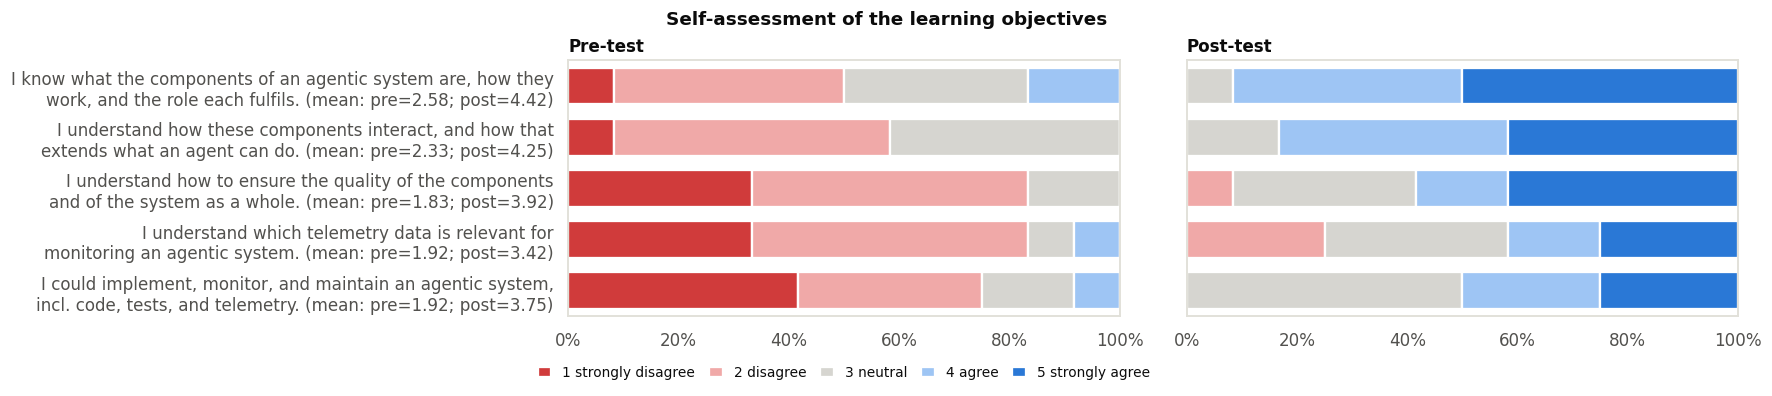

In [7]:
fig = plot_agreement(B1_TEXT, "Self-assessment of the learning objectives")
save_pdf(fig, "b1_learning_objectives")
plt.show()

## B2 per component: "I could explain it" and "I could implement it"

Mean rating per component, pre and post, over the students with at least 5 quiz items answered at both waves who rated that component at both waves. $\Delta M$
in the title is the mean change pooled over every component rating given at both waves.

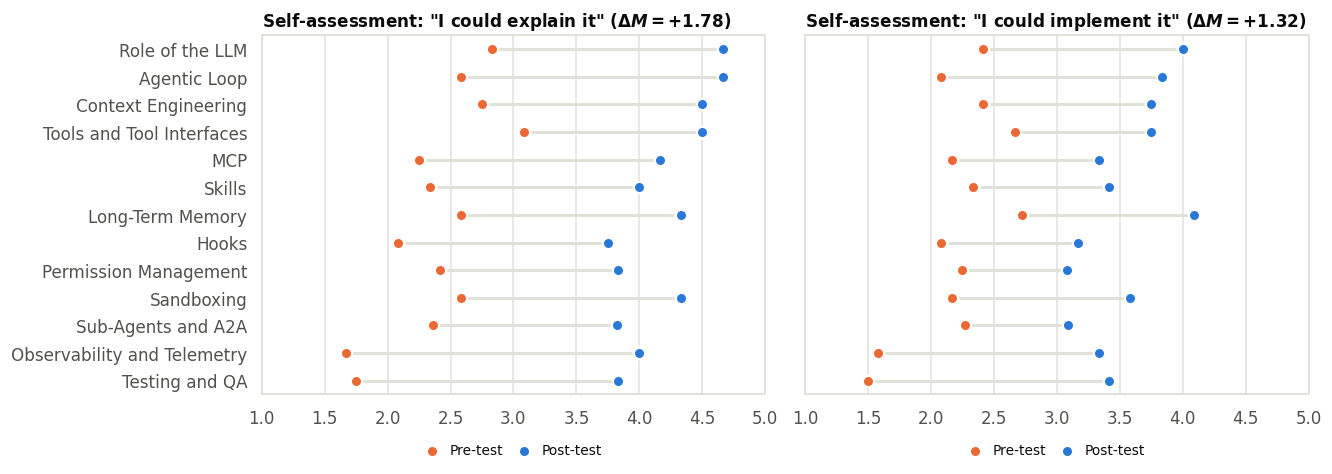

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True, sharey=True)
for ax, kind, title in [(axes[0], "expl", 'Self-assessment: "I could explain it"'),
                        (axes[1], "impl", 'Self-assessment: "I could implement it"')]:
    items = [f"b2_{kind}_{c}" for c in B2_COMPONENTS]
    ratings = {wave: wave_items(items, wave, paired_only=True).astype(float) for wave in WAVES}
    means = pd.DataFrame({wave: ratings[wave].mean().to_numpy() for wave in WAVES}, index=B2_COMPONENTS)
    mean_change = (ratings["post"] - ratings["pre"]).stack().mean()
    y = np.arange(len(means))
    ax.hlines(y, means.min(axis=1), means.max(axis=1), color=GRID, linewidth=2)
    for wave, label in zip(WAVES, ["Pre-test", "Post-test"]):
        ax.scatter(means[wave], y, s=55, color=WAVE_COLORS[wave], edgecolor=SURFACE, linewidth=1.5, zorder=3, label=label)
    ax.set_yticks(y, [B2_TEXT[c] for c in B2_COMPONENTS])
    ax.set_ylim(len(y) - 0.5, -0.5)
    ax.set_xlim(1, 5)
    ax.grid(axis="y", visible=False)
    # Straight quotes and \\boldsymbol keep the whole title bold (curly quotes and plain math fall back to regular).
    ax.set_title(f"{title} ($\\boldsymbol{{\\Delta M = {mean_change:+.2f}}}$)")
    legend_below(ax, 2)
save_pdf(fig, "b2_components")
plt.show()

## B3 confidence, pre and post side by side

Paired students with at least 5 quiz items answered at both waves; per item, only students who rated that item at both waves.

Confidence in applying the course content: “I am confident that I could …”: n=13


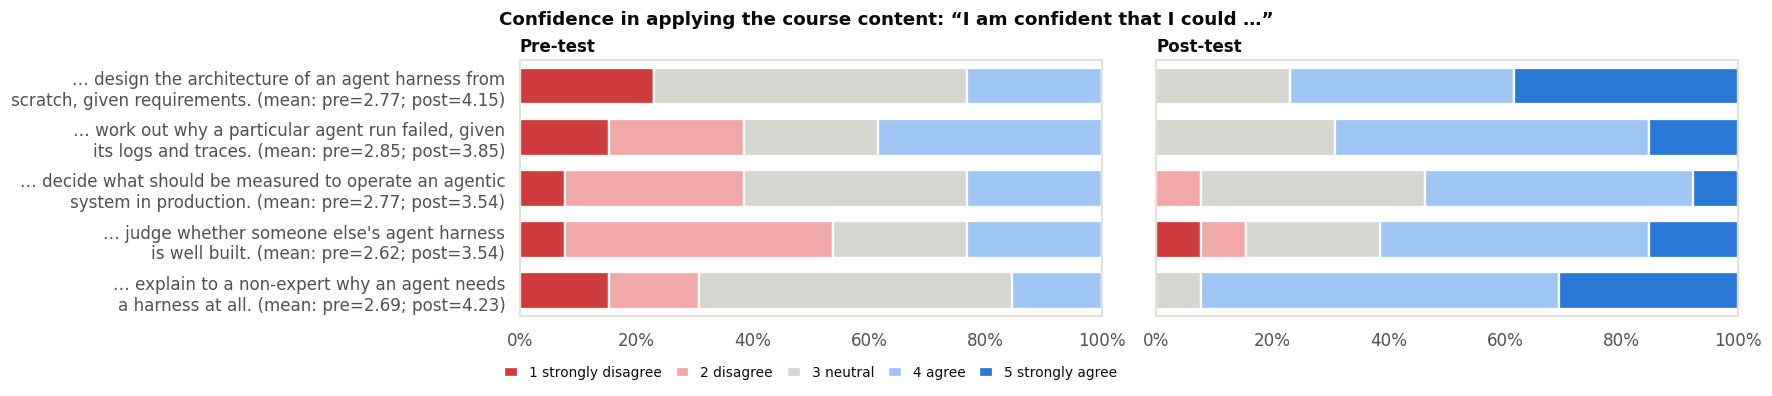

In [9]:
fig = plot_agreement(B3_TEXT, "Confidence in applying the course content: “I am confident that I could …”")
save_pdf(fig, "b3_confidence")
plt.show()

## Demographics (Part A)

A1 degree program, A2 semester and A4 professional software development experience. One column per answer (answers
that no student gave are left out; degree programs abbreviated CS and AIEng); each cell gives pre / post: the students with at least 5 quiz items answered at the pre-test / at the post-test. Part A is asked only at
the pre-test, so the post column shows the pre-test answers of the students in the post-test sample. Each question is
counted on its own (no cross-tabulation, see the reporting rules in `docs/analysis_plan.md`); a blank or out-of-range
answer, or no returned pre-test, counts as "no answer". Percentages are of all students in that column.

In [10]:
PROGRAMME_ACRONYMS = {"M.Sc. Computer Science": "CS", "M.Sc. Artificial Intelligence Engineering": "AIEng"}


def answer_counts(rows, var):
    """Counts per answer code of one Part A question, plus 'no answer', over the given rows of raw."""
    labels = value_labels(var)
    values = pd.to_numeric(raw.loc[rows, var], errors="coerce")
    counts = values.where(values.isin(list(labels))).value_counts().reindex(list(labels), fill_value=0)
    counts.index = [PROGRAMME_ACRONYMS.get(labels[c], labels[c]) for c in counts.index]
    counts["no answer"] = len(rows) - counts.sum()
    return counts


samples = {wave: raw.index[has_wave[wave] & quiz_ok[wave]] for wave in WAVES}
print("Students with at least", MIN_ANSWERED, "quiz items answered:", {w: len(s) for w, s in samples.items()})
# Post-test students whose code matched no returned pre-test: they have no Part A answers and count as "no answer".
n_post_no_pre = int((~has_wave["pre"][samples["post"]]).sum())
print("Post-test sample without a returned pre-test:", n_post_no_pre)
no_pre_note = ("" if n_post_no_pre == 0 else
               f" {['One', 'Two', 'Three', 'Four', 'Five'][n_post_no_pre - 1] if n_post_no_pre <= 5 else n_post_no_pre}"
               f" of the post-test students {'has' if n_post_no_pre == 1 else 'have'} no matching "
               f"pre-test and {'counts' if n_post_no_pre == 1 else 'count'} as ``no answer''.")
tables = []
for var, question in [("programme", "Degree program"), ("semester", "Semester"),
                      ("prof_exp", "Professional development experience")]:
    counts = pd.DataFrame({wave: answer_counts(samples[wave], var) for wave in WAVES})
    counts = counts[counts.sum(axis=1) > 0]
    share = 100 * counts / pd.Series({w: len(s) for w, s in samples.items()})
    tables.append(pd.DataFrame({
        "n (pre / post)": counts["pre"].astype(str) + " / " + counts["post"].astype(str),
        "% (pre / post)": share["pre"].map("{:.0f}".format) + " / " + share["post"].map("{:.0f}".format),
    }).rename_axis("answer").assign(question=question).set_index("question", append=True).swaplevel())
if raw.loc[samples["pre"].union(samples["post"]), "programme_other"].notna().any():
    print("A1 'other' free text given")
# Transposed: one column per answer, grouped by question; rows n and %.
demographics = pd.concat(tables).T
display(demographics)

groups = demographics.columns.get_level_values("question")
spans = [(q, (groups == q).sum()) for q in dict.fromkeys(groups)]
starts = np.cumsum([2] + [n for _, n in spans])
lines = [
    r"\begin{table*}",
    r"\centering",
    r"\small",
    r"\setlength{\tabcolsep}{3pt}",
    rf"\caption{{Demographics. Each cell gives pre\,/\,post: the {len(samples['pre'])} students with at "
    rf"least {MIN_ANSWERED} quiz items answered at the pre-test\,/\,the {len(samples['post'])} students with at least "
    rf"{MIN_ANSWERED} answered at the post-test, with their pre-test answers.{no_pre_note} Percentages are of all "
    r"students in that sample.}",
    r"\label{tab:demographics}",
    r"\begin{tabular}{l" + "c" * len(demographics.columns) + "}",
    r"\toprule",
    # A4 header shortened to fit over its six columns; "in years" lets the answer headers drop "years".
    " & ".join([""] + [rf"\multicolumn{{{n}}}{{c}}{{{tex(q.replace('development experience', 'experience in years'))}}}"
                       for q, n in spans]) + r" \\",
    "".join(rf"\cmidrule(lr){{{a}-{a + n - 1}}}" for a, (_, n) in zip(starts, spans)),
    " & ".join([""] + [tex_header(a.removesuffix(" years").removesuffix(" year"))
                       for a in demographics.columns.get_level_values("answer")]) + r" \\",
    r"\midrule",
    *[" & ".join([pre_post_cell(tex(row)).replace("n (", "$n$ (")] + [pre_post_cell(v) for v in values]) + r" \\" for row, values in demographics.iterrows()],
    r"\bottomrule",
    r"\end{tabular}",
    r"\end{table*}",
]
save_tex("\n".join(lines) + "\n", "demographics")

Students with at least 5 quiz items answered: {'pre': 29, 'post': 15}
Post-test sample without a returned pre-test: 1


question       Degree program                    Semester                   \
answer                     CS    AIEng no answer      1-2      3-4     5-6   
n (pre / post)         15 / 7   13 / 7     1 / 1   13 / 7    7 / 5   5 / 1   
% (pre / post)        52 / 47  45 / 47     3 / 7  45 / 47  24 / 33  17 / 7   

question                        Professional development experience           \
answer            7-8 no answer                                none  <1 year   
n (pre / post)  1 / 0     3 / 2                               6 / 3    8 / 4   
% (pre / post)  3 / 0   10 / 13                             21 / 20  28 / 27   

question                                               
answer         1-2 years 2-5 years >5 years no answer  
n (pre / post)     6 / 2     7 / 4    1 / 1     1 / 1  
% (pre / post)   21 / 13   24 / 27    3 / 7     3 / 7

## Prior knowledge sources (Part A, pre-test)

A3 courses already passed and A8 where prior knowledge about LLMs and agents comes from; both are multi-select, so the
percentages of a question do not add up to 100. Same pre / post samples as the demographics table. One row per option
(options no student ticked are left out); "no answer" counts the students who ticked nothing in that question or
returned no pre-test. Percentages are of all students in that column.

In [11]:
def ticked_counts(rows, options):
    """Students per ticked option of a multi-select question (only code 1 counts as ticked), plus 'no answer'."""
    ticks = raw.loc[rows, options] == 1
    counts = ticks.sum().rename(short_label)
    counts["no answer"] = (~ticks.any(axis=1)).sum()
    return counts


tables = []
for prefix, question in [("course_", "Courses already passed"),
                         ("source_", "Sources of knowledge about LLMs and agents")]:
    options = [v for v in codebook.index if v.startswith(prefix)]
    counts = pd.DataFrame({wave: ticked_counts(samples[wave], options) for wave in WAVES})
    counts = counts[counts.sum(axis=1) > 0]
    share = 100 * counts / pd.Series({w: len(s) for w, s in samples.items()})
    tables.append(pd.DataFrame({
        "n (pre / post)": counts["pre"].astype(str) + " / " + counts["post"].astype(str),
        "% (pre / post)": share["pre"].map("{:.0f}".format) + " / " + share["post"].map("{:.0f}".format),
    }).rename_axis("option").assign(question=question).set_index("question", append=True).swaplevel())
knowledge_sources = pd.concat(tables)
display(knowledge_sources)

lines = [
    r"\begin{table}",
    r"\centering",
    r"\footnotesize",
    rf"\caption{{Prior knowledge for the same samples as "
    r"Table~\ref{tab:demographics}. Percentages are of all students in that sample; ``no answer'' counts the "
    r"students who ticked nothing in that question" + ("" if n_post_no_pre == 0 else " or have no matching pre-test")
    + ".}",
    r"\label{tab:knowledge-sources}",
    r"\begin{tabular}{@{}p{4.9cm}cc@{}}",
    r"\toprule",
    r"& $n$ & \% \\",
    r"& pre\,/\,post & pre\,/\,post \\",
]
for question, block in knowledge_sources.groupby(level="question", sort=False):
    lines += [r"\midrule", rf"\multicolumn{{3}}{{@{{}}l}}{{\textit{{{tex(question)}}}}} \\"]
    for (_, option), row in block.iterrows():
        lines.append(" & ".join([r"\raggedright\hangindent=1em " + tex(option)] + [pre_post_cell(v) for v in row]) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
save_tex("\n".join(lines) + "\n", "knowledge_sources")

n (pre / post)  \
question                                   option                                                              
Courses already passed                     Foundations of AI Engineering                               4 / 2   
                                           Introduction to Deep Learning                               6 / 3   
                                           Deep Learning for Natural Language and Code                 7 / 5   
                                           Principles of AI Engineering                                3 / 1   
                                           Lab Courses on Machine Learning and Data Science            5 / 3   
                                           Additional Lectures on Machine Learning and Dat...          4 / 2   
                                           Software Engineering                                        5 / 3   
                                           Software Testing                                            2 / 1   
                                           Lab Course of Software Engineering with AI                  1 / 0   
                                           Additional Lectures on Software Engineering                 2 / 2   
                                           none of the above                                          12 / 5   
                                           no answer                                                   0 / 1   
Sources of knowledge about LLMs and agents university courses                                         12 / 8   
                                           self-study                                                24 / 10   
                                           work/internship                                            10 / 3   
                                           hobby projects                                             17 / 7   
                                           peers                                                       9 / 6   
                                           essentially none                                            1 / 1   
                                           no answer                                                   1 / 2   

                                                                                              % (pre / post)  
question                                   option                                                             
Courses already passed                     Foundations of AI Engineering                             14 / 13  
                                           Introduction to Deep Learning                             21 / 20  
                                           Deep Learning for Natural Language and Code               24 / 33  
                                           Principles of AI Engineering                               10 / 7  
                                           Lab Courses on Machine Learning and Data Science          17 / 20  
                                           Additional Lectures on Machine Learning and Dat...        14 / 13  
                                           Software Engineering                                      17 / 20  
                                           Software Testing                                            7 / 7  
                                           Lab Course of Software Engineering with AI                  3 / 0  
                                           Additional Lectures on Software Engineering                7 / 13  
                                           none of the above                                         41 / 33  
                                           no answer                                                   0 / 7  
Sources of knowledge about LLMs and agents university courses                                        41 / 53  
                                           self-study                       

## A5–A7 prior skills and experience, pre and post side by side

Part A is asked only at the pre-test. The two panels use the samples of the demographics table: the students with at
least 5 quiz items answered at the pre-test / at the post-test, each with their pre-test answers; per item, only the
students who rated it. The A5 item labels carry the pre and post means; the n per item is printed (for the caption),
not plotted.

Self-rated technical skills (pre): n=29
Self-rated technical skills (post): n=13–14 per item


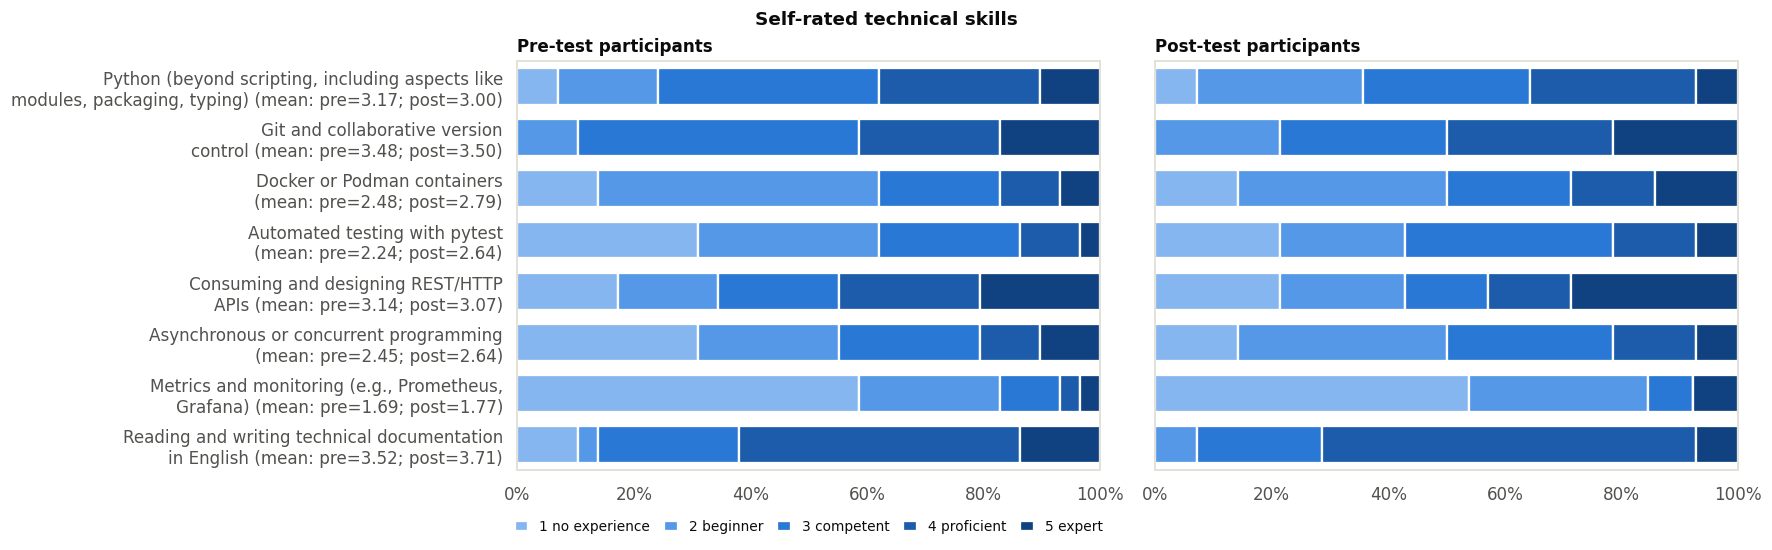

Use of AI tools: “How often do you currently use …” (pre): n=29
Use of AI tools: “How often do you currently use …” (post): n=14


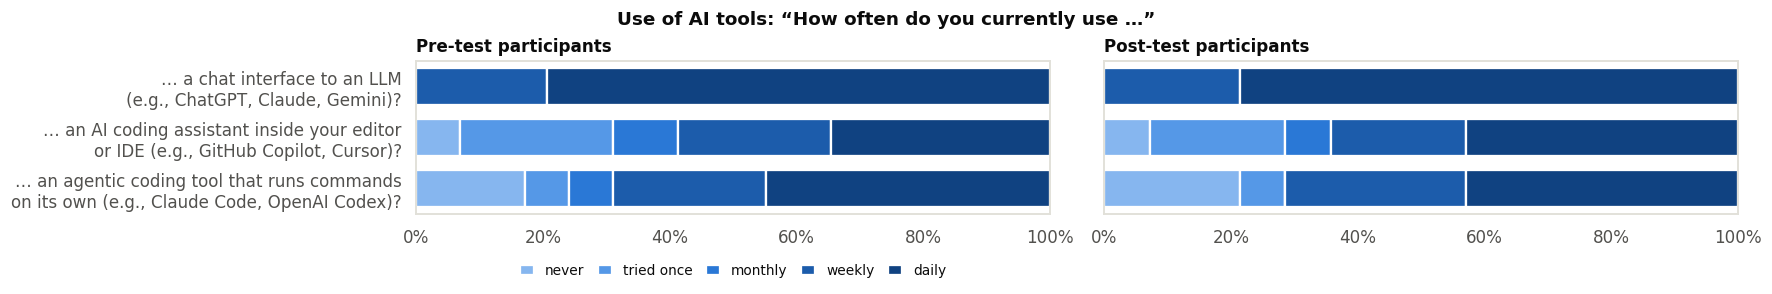

Prior experience with LLM components: “Have you ever, yourself, …” (pre): n=28–29 per item
Prior experience with LLM components: “Have you ever, yourself, …” (post): n=13–14 per item


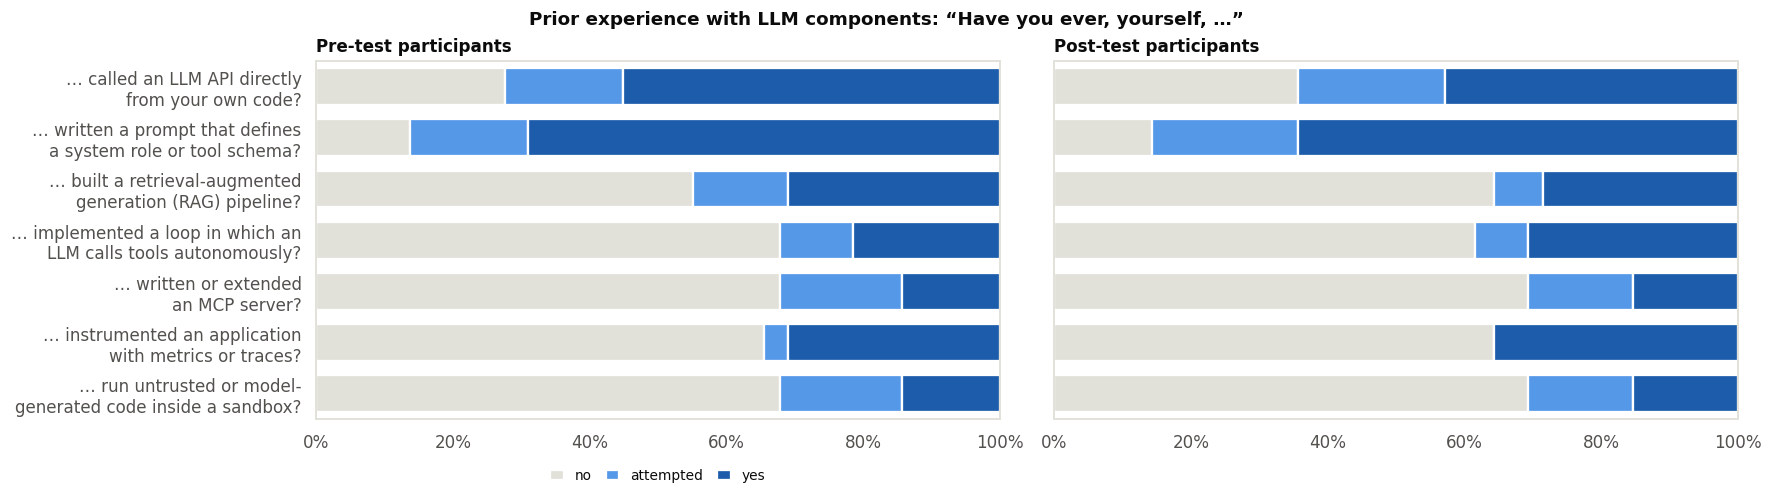

In [12]:
# --- Part A item wording (survey/common/part_a_demographics.tex) -------------------------------
A5_TEXT = {
    "skill_python": "Python (beyond scripting, including aspects like modules, packaging, typing)",
    "skill_git": "Git and collaborative version control",
    "skill_container": "Docker or Podman containers",
    "skill_pytest": "Automated testing with pytest",
    "skill_api": "Consuming and designing REST/HTTP APIs",
    "skill_async": "Asynchronous or concurrent programming",
    "skill_metrics": "Metrics and monitoring (e.g., Prometheus, Grafana)",
    "skill_english": "Reading and writing technical documentation in English",
}
A6_TEXT = {
    "use_chat": "… a chat interface to an LLM (e.g., ChatGPT, Claude, Gemini)?",
    "use_assistant": "… an AI coding assistant inside your editor or IDE (e.g., GitHub Copilot, Cursor)?",
    "use_agentic": "… an agentic coding tool that runs commands on its own (e.g., Claude Code, OpenAI Codex)?",
}
A7_TEXT = {
    "built_api": "… called an LLM API directly from your own code?",
    "built_prompt": "… written a prompt that defines a system role or tool schema?",
    "built_rag": "… built a retrieval-augmented generation (RAG) pipeline?",
    "built_loop": "… implemented a loop in which an LLM calls tools autonomously?",
    "built_mcp": "… written or extended an MCP server?",
    "built_telemetry": "… instrumented an application with metrics or traces?",
    "built_sandbox": "… run untrusted or model-generated code inside a sandbox?",
}
ABILITY = {1: "1 no experience", 2: "2 beginner", 3: "3 competent", 4: "4 proficient", 5: "5 expert"}


def part_a_items(items, labels, wave):
    """Part A items (asked at the pre-test) of the students in one wave's sample; codes outside labels -> missing."""
    frame = raw.loc[samples[wave], list(items)].apply(pd.to_numeric, errors="coerce")
    return frame.where(frame.isin(list(labels))).astype("Int64")


def plot_part_a(texts, labels, colors, suptitle, name, show_mean=False):
    """One Part A grid as stacked bars, pre and post samples side by side, laid out like plot_agreement.
    Prints the n per item and wave (for the caption)."""
    frames = {wave: part_a_items(texts, labels, wave) for wave in WAVES}
    for wave, frame in frames.items():
        n = frame.notna().sum()
        print(f"{suptitle} ({wave}): n={n.min()}" + ("" if n.min() == n.max() else f"–{n.max()} per item"))
    means = {wave: frame.astype(float).mean() for wave, frame in frames.items()}
    labels_rows = {v: wrap_balanced(f"{text} (mean: pre={means['pre'][v]:.2f}; post={means['post'][v]:.2f})"
                                    if show_mean else text) for v, text in texts.items()}
    fig, axes = plt.subplots(1, 2, figsize=(16, 0.55 * len(texts) + 2), constrained_layout=True, sharey=True)
    for ax, wave, wave_title in zip(axes, WAVES, ["Pre-test participants", "Post-test participants"]):
        plot_stacked(ax, frames[wave], labels, colors, labels_rows, wave_title, label_width=None,
                     legend=wave == "pre")
    fig.suptitle(suptitle, fontweight="bold", fontsize=12)
    fit_rows(fig, axes[0], len(texts))
    save_pdf(fig, name)
    plt.show()


plot_part_a(A5_TEXT, ABILITY, ORDINAL_5, "Self-rated technical skills", "a5_skills", show_mean=True)
plot_part_a(A6_TEXT, value_labels("use_chat"), ORDINAL_5, "Use of AI tools: “How often do you currently use …”",
            "a6_ai_tool_use")
plot_part_a(A7_TEXT, value_labels("built_api"), [GRID, ORDINAL_5[1], ORDINAL_5[3]],
            "Prior experience with LLM components: “Have you ever, yourself, …”", "a7_llm_experience")

## A′3–A′6 what students did during the lab (post-test)

Part A′ is asked only at the post-test, so there is one panel per question instead of pre and post side by side. The
sample is the post-test sample of the demographics table: the students with at least 5 quiz items answered at the
post-test; per item, only the students who answered it. A′3 involvement per harness component ("reviewed only" means
reading and understanding a teammate's code without writing it), A′4 AI assistance for the student's own lab work,
A′5 how much of their submitted code they could explain line by line, A′6 what they learned from. The item labels of
A′4–A′6 carry the means; the n per item is printed (for the caption), not plotted. Single-panel figures are half as wide
as the two-panel ones, so at `\columnwidth` their text matches the `\textwidth` figures.

Own involvement per harness component: n=12–14 per item


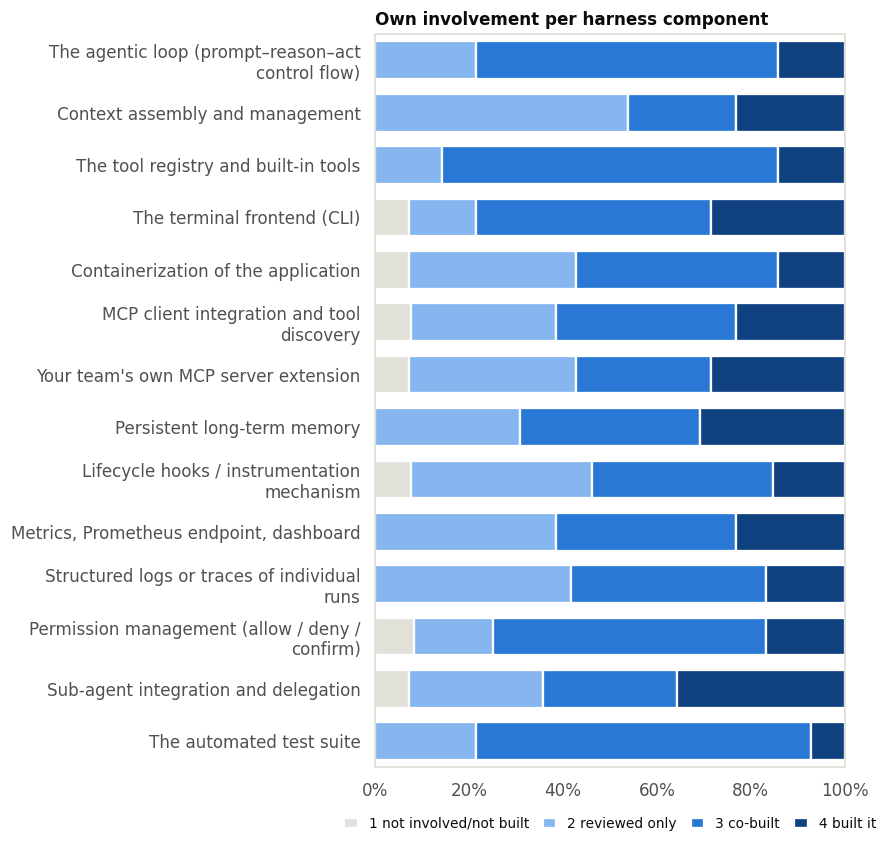

Use of AI assistance (LLMs, coding agents): n=14
Own code the student could explain line by line: n=14


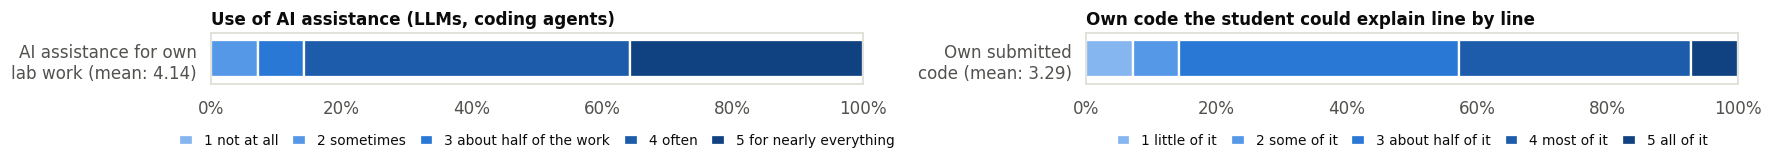

Sources of learning: “I learned a lot from …”: n=14


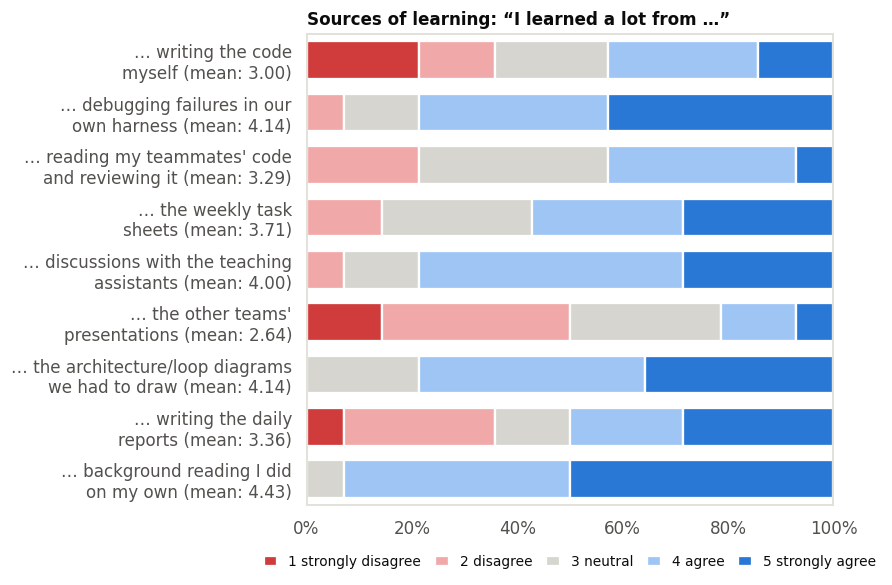

In [13]:
# --- Part A′ item wording (survey/common/part_a_exposure.tex) ----------------------------------
A3_POST_TEXT = {
    "own_loop": "The agentic loop (prompt–reason–act control flow)",
    "own_context": "Context assembly and management",
    "own_tools": "The tool registry and built-in tools",
    "own_cli": "The terminal frontend (CLI)",
    "own_container": "Containerization of the application",
    "own_mcpclient": "MCP client integration and tool discovery",
    "own_mcpserver": "Your team's own MCP server extension",
    "own_memory": "Persistent long-term memory",
    "own_hooks": "Lifecycle hooks / instrumentation mechanism",
    "own_metrics": "Metrics, Prometheus endpoint, dashboard",
    "own_traces": "Structured logs or traces of individual runs",
    "own_perm": "Permission management (allow / deny / confirm)",
    "own_subagent": "Sub-agent integration and delegation",
    "own_tests": "The automated test suite",
}
A6_POST_TEXT = {
    "learned_01": "… writing the code myself",
    "learned_02": "… debugging failures in our own harness",
    "learned_03": "… reading my teammates' code and reviewing it",
    "learned_04": "… the weekly task sheets",
    "learned_05": "… discussions with the teaching assistants",
    "learned_06": "… the other teams' presentations",
    "learned_07": "… the architecture/loop diagrams we had to draw",
    "learned_08": "… writing the daily reports",
    "learned_09": "… background reading I did on my own",
}


def numbered(labels):
    """{4: 'built it', ...} -> {4: '4 built it', ...}, as in the Part A and B legends."""
    return {code: f"{code} {label}" for code, label in labels.items()}


def plot_post(ax, texts, labels, colors, title, show_mean=False):
    """One Part A′ grid (post-test sample) as stacked bars. Prints the n per item (for the caption)."""
    frame = part_a_items(texts, labels, "post")
    n = frame.notna().sum()
    print(f"{title}: n={n.min()}" + ("" if n.min() == n.max() else f"–{n.max()} per item"))
    means = frame.astype(float).mean()
    rows = {v: wrap_balanced(f"{text} (mean: {means[v]:.2f})") if show_mean else text for v, text in texts.items()}
    plot_stacked(ax, frame, labels, colors, rows, title, label_width=None if show_mean else 40)


fig, ax = plt.subplots(figsize=(8, 0.4 * len(A3_POST_TEXT) + 1.4), constrained_layout=True)
plot_post(ax, A3_POST_TEXT, numbered(value_labels("own_loop")), [GRID, ORDINAL_5[0], ORDINAL_5[2], ORDINAL_5[4]],
          "Own involvement per harness component")
fit_rows(fig, ax, len(A3_POST_TEXT))
save_pdf(fig, "post_a3_involvement")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 1.9), constrained_layout=True)
plot_post(axes[0], {"ai_intensity": "AI assistance for own lab work"}, numbered(value_labels("ai_intensity")),
          ORDINAL_5, "Use of AI assistance (LLMs, coding agents)", show_mean=True)
plot_post(axes[1], {"can_explain_code": "Own submitted code"}, numbered(value_labels("can_explain_code")), ORDINAL_5,
          "Own code the student could explain line by line", show_mean=True)
fit_rows(fig, axes[0], 1)
save_pdf(fig, "post_a4_a5_ai_use_understanding")
plt.show()

fig, ax = plt.subplots(figsize=(8, 0.42 * len(A6_POST_TEXT) + 1.4), constrained_layout=True)
plot_post(ax, A6_POST_TEXT, AGREE, DIVERGING_5, "Sources of learning: “I learned a lot from …”", show_mean=True)
fit_rows(fig, ax, len(A6_POST_TEXT))
save_pdf(fig, "post_a6_learning_sources")
plt.show()


## Numbers reported in the paper

Every number in the text of `paper/main.tex`, in the order of the paper, with the samples of the figures and
tables above. Percentages are of the students who answered the item, unless stated otherwise.

In [14]:
# --- Numbers in the text of paper/main.tex, in the order of the paper ------------------------------
def section(title):
    print(f"\n=== {title}")


def pct(flags):
    """Share of True among the non-missing values, in percent."""
    flags = flags.dropna().astype(bool)
    return 100 * flags.mean()


def shares(frame, groups):
    """Per item (column): percentage of the non-missing answers in each group {name: list of codes}."""
    return pd.DataFrame({name: frame.apply(lambda s: pct(s.isin(codes).where(s.notna())))
                         for name, codes in groups.items()}).round(0).astype(int)


def mean_table(frames, texts):
    """Mean and % agree (4-5) per Part B item at both waves, with the item text shortened."""
    return pd.DataFrame({
        "pre mean": frames["pre"].astype(float).mean(), "post mean": frames["post"].astype(float).mean(),
        "pre % agree": frames["pre"].apply(lambda s: pct((s >= 4).where(s.notna()))),
        "post % agree": frames["post"].apply(lambda s: pct((s >= 4).where(s.notna()))),
    }).round({"pre mean": 2, "post mean": 2, "pre % agree": 0, "post % agree": 0}).rename(
        index=lambda v: texts[v][:60])


section("Method: quiz items per cognitive level")
levels = pd.Series({q: re.search(r"\(T\d+, week [^,]+, ([^,]+),", codebook.at[f"{q}_resp", "label"])[1]
                    for q in ITEMS})
print(levels.value_counts().to_dict())

section("Participants and data preparation")
print(f"Returned at least one questionnaire: {(has_wave['pre'] | has_wave['post']).sum()}; pre {has_wave['pre'].sum()}, "
      f"post {has_wave['post'].sum()}, both {(has_wave['pre'] & has_wave['post']).sum()}")
print(f"At least {MIN_ANSWERED} quiz items answered: pre {quiz_ok['pre'].sum()}, post {quiz_ok['post'].sum()}, "
      f"both {quiz_ok.all(axis=1).sum()}")
no_pre = quiz_ok["post"] & ~quiz_ok["pre"]
print(f"Usable post-test without usable pre-test: {no_pre.sum()} (no matching pre-test code: "
      f"{(no_pre & ~has_wave['pre']).sum()}, pre-test with < {MIN_ANSWERED} items answered: "
      f"{(no_pre & has_wave['pre']).sum()})")
print(f"Complete quiz (at least {FULL_ANSWERED} answered) in both tests: {full.all(axis=1).sum()}")
print(f"Paired students for the self-assessment: {len(df)}")
print(f"Paired students of the pre-test sample: {quiz_ok.all(axis=1).sum()} of {quiz_ok['pre'].sum()}")

section("Results: demographics and prior knowledge, pre-test sample (% of the sample)")
n_pre = len(samples["pre"])
for var in ["programme", "semester", "prof_exp"]:
    print(var, (100 * answer_counts(samples["pre"], var) / n_pre).round(0).astype(int).to_dict())
for prefix in ["course_", "source_"]:
    options = [v for v in codebook.index if v.startswith(prefix)]
    print(prefix, (100 * ticked_counts(samples["pre"], options) / n_pre).round(0).astype(int).to_dict())

section("Results: A5 skills (mean; % with no experience), pre-test sample")
a5 = {wave: part_a_items(A5_TEXT, ABILITY, wave) for wave in WAVES}
a5_means = pd.DataFrame({wave: a5[wave].astype(float).mean() for wave in WAVES})
print(pd.DataFrame({"mean": a5_means["pre"].round(2), "% none": shares(a5["pre"], {"none": [1]})["none"]})
      .sort_values("mean", ascending=False).to_string())

section("Results: A6 use of AI tools (% of answers), pre-test sample")
a6 = {wave: part_a_items(A6_TEXT, value_labels("use_chat"), wave) for wave in WAVES}
A6_GROUPS = {"never": [1], "at least weekly": [4, 5], "daily": [5]}
print(shares(a6["pre"], A6_GROUPS).to_string())

section("Results: A7 prior experience (% of answers), pre-test sample")
a7 = {wave: part_a_items(A7_TEXT, value_labels("built_api"), wave) for wave in WAVES}
A7_GROUPS = {"yes": [3], "attempted or yes": [2, 3]}
print(shares(a7["pre"], A7_GROUPS).to_string())

section("Results: post-test sample against pre-test sample")
print(f"Post-test sample: n={len(samples['post'])}")
print(f"A5 mean skill ratings, largest difference: {(a5_means['post'] - a5_means['pre']).abs().max():.2f}")
print("A6 and A7 (pre / post sample):")
for frames, groups in [(a6, A6_GROUPS), (a7, A7_GROUPS)]:
    both_samples = shares(frames["pre"], groups).astype(str) + " / " + shares(frames["post"], groups).astype(str)
    print(both_samples.to_string())
pre_scores = totals["pre"].dropna()
with_post = pre_scores.index.isin(totals["post"].dropna().index)
print(f"Median pre-test quiz score: with usable post-test {pre_scores[with_post].median():g} (n={with_post.sum()}), "
      f"without {pre_scores[~with_post].median():g} (n={(~with_post).sum()})")

section("Results: A′2 hours per week, post-test sample")
hours = part_a_items({"hours_week": "Hours per week"}, value_labels("hours_week"), "post")["hours_week"]
hours_labels = value_labels("hours_week")
print(pd.DataFrame({"n": hours.value_counts().reindex(list(hours_labels), fill_value=0),
                    "% of answers": (100 * hours.value_counts(normalize=True)).reindex(list(hours_labels), fill_value=0)
                    .round(0).astype(int)}).rename(index=hours_labels).to_string())
print(f"answered: {hours.notna().sum()} of {len(hours)}")

section("Results: A′3 involvement per component (% of answers), post-test sample")
a3 = part_a_items(A3_POST_TEXT, value_labels("own_loop"), "post")
a3_shares = shares(a3, {"not involved": [1], "reviewed only": [2], "co-built": [3], "built alone": [4],
                        "built or co-built": [3, 4]}).assign(n=a3.notna().sum())
print(a3_shares.rename(index=lambda v: A3_POST_TEXT[v][:45]).to_string())

section("Results: A′4 AI assistance and A′5 explaining the own code, post-test sample")
for var in ["ai_intensity", "can_explain_code"]:
    answers = part_a_items({var: var}, value_labels(var), "post")[var]
    print(var, answers.value_counts().reindex(list(value_labels(var)), fill_value=0)
          .rename(index=value_labels(var)).to_dict(), f"n={answers.notna().sum()}, mean {answers.astype(float).mean():.2f}")

section("Results: A′6 sources of learning, post-test sample")
a6_post = part_a_items(A6_POST_TEXT, AGREE, "post")
print(pd.DataFrame({"mean": a6_post.astype(float).mean().round(2),
                    "% agree": shares(a6_post, {"agree": [4, 5]})["agree"],
                    "% disagree": shares(a6_post, {"disagree": [1, 2]})["disagree"]})
      .rename(index=A6_POST_TEXT).sort_values("mean", ascending=False).to_string())

section("Results: quiz scores")
for wave in WAVES:
    t = totals[wave].dropna()
    print(f"{wave}: n={len(t)}, median {t.median():g} (IQR {t.quantile(0.25):g}-{t.quantile(0.75):g})")
paired_totals = totals.dropna()
gain = paired_totals["post"] - paired_totals["pre"]
print(f"Paired: n={len(gain)}, improved {(gain > 0).sum()}, median gain {gain.median():+g}, mean {gain.mean():+.1f}, "
      f"range {gain.min():+g} to {gain.max():+g}")
for wave in WAVES:
    responses = quiz_long[(quiz_long["wave"] == wave) & quiz_long["student"].isin(quiz_ok.index[quiz_ok[wave]])]
    print(f"{wave}: 'I do not know' for {100 * (responses['response'] == 'dk').mean():.0f}% of the responses")

section("Results: quiz items (tests with at least MIN_ANSWERED answered, as in the per-item figure)")
p_item = 100 * quiz.groupby(["item", "wave"])["score"].mean().unstack()[WAVES].reindex(ITEMS)
p_item["gain"] = p_item["post"] - p_item["pre"]
for wave in WAVES:
    print(f"{wave}: {p_item[wave].min():.0f}%-{p_item[wave].max():.0f}% correct per item, "
          f"{(p_item[wave] < 25).sum()} items below chance")
print(f"Items that improved: {(p_item['gain'] > 0).sum()} of {len(ITEMS)}")
pre_quiz = quiz[quiz["wave"] == "pre"]
dk = pre_quiz.groupby("item")["response"].agg(lambda s: 100 * (s == "dk").mean())
blank = pre_quiz.groupby("item")["response"].agg(lambda s: 100 * s.isna().mean())
given = pre_quiz[pre_quiz["response"].isin(list("abcd"))]
given_item = 100 * given.groupby("item")["score"].mean()
print(f"Pre-test: 'I do not know' {dk.min():.0f}%-{dk.max():.0f}% per item, blanks at most {blank.max():.0f}%; "
      f"of the given answers {100 * given['score'].mean():.0f}% correct ({given_item.min():.0f}%-{given_item.max():.0f}% "
      f"per item); below 40%: {given_item[given_item < 40].round(0).astype(int).to_dict()}")
print(p_item.round(0).astype(int).rename(index=ITEM_LABELS).sort_values("gain", ascending=False).to_string())

section("Results: B1 learning objectives (paired, per item only students who rated it at both tests)")
b1 = {wave: wave_items(list(B1_TEXT), wave, paired_only=True) for wave in WAVES}
print(f"n={b1['pre'].notna().sum().min()}-{b1['pre'].notna().sum().max()}")
print(mean_table(b1, B1_TEXT).to_string())

section("Results: B2 components (paired, per item only students who rated it at both tests)")
b2 = {}
for kind in ["expl", "impl"]:
    items = [f"b2_{kind}_{c}" for c in B2_COMPONENTS]
    ratings = {wave: wave_items(items, wave, paired_only=True).astype(float).set_axis(B2_COMPONENTS, axis=1)
               for wave in WAVES}
    print(f"{kind}: mean change pooled over all ratings {(ratings['post'] - ratings['pre']).stack().mean():+.2f}")
    b2[kind] = pd.DataFrame({wave: ratings[wave].mean() for wave in WAVES})
b2 = pd.concat(b2, axis=1)
for kind in ["expl", "impl"]:
    b2[kind, "gain"] = b2[kind, "post"] - b2[kind, "pre"]
for wave in WAVES:
    diff = b2["expl", wave] - b2["impl", wave]
    print(f"{wave}: explain - implement per component {diff.min():+.2f} to {diff.max():+.2f}, "
          f"implement below explain for {(diff > 0).sum()} of {len(diff)}")
print(b2.round(2).rename(index=B2_TEXT).sort_values(("expl", "gain"), ascending=False).to_string())

section("Results: B3 confidence (paired, per item only students who rated it at both tests)")
b3 = {wave: wave_items(list(B3_TEXT), wave, paired_only=True) for wave in WAVES}
print(f"n={b3['pre'].notna().sum().min()}-{b3['pre'].notna().sum().max()}")
print(mean_table(b3, B3_TEXT).to_string())


=== Method: quiz items per cognitive level
{'understand': 9, 'apply-analyse': 6, 'remember': 5}

=== Participants and data preparation
Returned at least one questionnaire: 35; pre 34, post 17, both 16
At least 5 quiz items answered: pre 29, post 15, both 13
Usable post-test without usable pre-test: 2 (no matching pre-test code: 1, pre-test with < 5 items answered: 1)
Complete quiz (at least 15 answered) in both tests: 11
Paired students for the self-assessment: 13
Paired students of the pre-test sample: 13 of 29

=== Results: demographics and prior knowledge, pre-test sample (% of the sample)
programme {'CS': 52, 'AIEng': 45, 'other': 0, 'no answer': 3}
semester {'1-2': 45, '3-4': 24, '5-6': 17, '7-8': 3, '9 or more': 0, 'no answer': 10}
prof_exp {'none': 21, '<1 year': 28, '1-2 years': 21, '2-5 years': 24, '>5 years': 3, 'no answer': 3}
course_ {'Foundations of AI Engineering': 14, 'Introduction to Deep Learning': 21, 'Deep Learning for Natural Language and Code': 24, 'Principles of 

Median pre-test quiz score: with usable post-test 5 (n=13), without 5 (n=16)

=== Results: A′2 hours per week, post-test sample
            n  % of answers
hours_week                 
<10         0             0
10-19       3            21
20-29       4            29
30-39       6            43
40 or more  1             7
answered: 14 of 15

=== Results: A′3 involvement per component (% of answers), post-test sample
                                               not involved  reviewed only  co-built  built alone  built or co-built   n
The agentic loop (prompt–reason–act control f             0             21        64           14                 79  14
Context assembly and management                           0             54        23           23                 46  13
The tool registry and built-in tools                      0             14        71           14                 86  14
The terminal frontend (CLI)                               7             14        50           2

Pre-test: 'I do not know' 31%-71% per item, blanks at most 17%; of the given answers 67% correct (30%-94% per item); below 40%: {'q01': 30, 'q09': 33}
wave                            pre  post  gain
item                                           
Q17: Sub-agents & A2A            14    80    66
Q12: Hooks                       24    87    63
Q01: LLM role & statelessness    21    80    59
Q06: Tools & tool design         38    93    55
Q02: Context engineering         38    87    49
Q08: MCP                         52   100    48
Q07: Tools & tool design         14    60    46
Q05: Loop & control flow         28    73    46
Q13: Hooks                       14    60    46
Q09: MCP                         10    53    43
Q18: Observability & telemetry   38    80    42
Q04: Loop & control flow         45    87    42
Q11: Long-term memory            38    80    42
Q15: Permission management       28    67    39
Q14: Permission management       31    67    36
Q20: Quality assurance           